In [1]:
# !pip install "numpy<2.0" pandas scikit-learn --force-reinstall (this is for Cagla's computer dont run)

In [2]:
# import os (this is for Cagla's computer dont run)
import numpy as np

In [3]:
try:
    import scipy.signal as signal
except ImportError:
    signal = None
    print("Warning: scipy is missing")

try:
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
except ImportError:
    LinearDiscriminantAnalysis = None
    print("Warning: scikit-learn is missing")

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print("Warning: matplotlib is missing")

In [4]:
def apply_bandpass_filter(data: np.ndarray,
                          fs: float,
                          lowcut: float = 1.0, 
                          highcut: float = 50.0) -> np.ndarray:
    """Step 1: Preprocess. Apply the Butterworth bandpass filter to remove noise."""
    if signal is None:
        return data

    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(4, [low, high], btype="band")

    # zero-phase filter along the sample dimension (axis=1) : this ensures the brainwaves
    # don't get shifted left or right in time.
    # filtfilt is a scipy function means forward-backward filter 
    # it runs the data through the filter forward (mainly left to right)
    # then takes that filtered data and runs it through the filter again but this time
    # it is backward (right to left)
    filtered_data = signal.filtfilt(b, a, data, axis=1)
    return filtered_data


def extract_features(data: np.ndarray, fs: float) -> np.ndarray:
    """Step 2: Extract features. Compress raw data into bands (Theta, Alpha, Beta)."""
    if signal is None: # safet check for the data, for scipy package
        return np.zeros(data.shape[0] * 3)

    nperseg = min(int(fs), data.shape[1]) # for number of points per segment, 1 second of the data
    
    # this is maths. uses welch means Welch's method: it converts the data 
    # from the time domain to frequency domain
    # psd (power spectral density) tells how much power or energy the brain is producing at 
    # those frequencies
    freqs, psd = signal.welch(data, fs, nperseg=nperseg)

    bands = {"theta": (4, 8), "alpha": (8, 12), "beta": (13, 30)}
    features = []

    for ch_idx in range(data.shape[0]):
        for band_name, (low, high) in bands.items():
            band_idx = np.logical_and(freqs >= low, freqs <= high) # np.logical_and is np function
            power = np.mean(psd[ch_idx, band_idx]) # psd looks for the current channel, zooms in on
            # only the indices that has been found for the current band and calculates average
            features.append(power)

    return np.asarray(features, dtype=float)

# n_features: the total number of features
# n_features : number of channels (in our case 3) * how many bands (again 3, theta, alpha, beta)
def get_trained_classifier(fs: float, window_sec: float, channels: list): 
    """Step 3: Train/Load Classifier (Left Hand, Right Hand, Leg, Rest)."""
    if LinearDiscriminantAnalysis is None: # safety check
        return None

    calibration_files = {
    
        "Leg": "LegsTraining.csv",
        "Rest": "RestTraining.csv"
    }
    
    x_train = [] # this will hold all feature numbers
    y_train = [] # this will hold the matching answers
    
    window_samples = int(window_sec * fs)
    step_samples = int(window_samples * 0.5)
    
    for label, filename in calibration_files.items():
        print(f" Learning {label.upper()} from {filename}...")
        
        raw_data = load_eeg_csv(filename)
        raw_data = raw_data[channels, :]
        clean_data = apply_bandpass_filter(raw_data, fs, lowcut = 1.0, highcut = 50.0)
        
        total_samples = clean_data.shape[1]
        for start_idx in range(0, total_samples - window_samples + 1, step_samples):
            end_idx = start_idx + window_samples
            epoch = clean_data[:, start_idx:end_idx]
            
            features = extract_features(epoch, fs)
            x_train.append(features)
            y_train.append(label)
            
    if len(x_train) == 0:
        print(" No data found, check for CSV files")
        return None
    
    print(f" Training LDA model on {len(x_train)} real brainwave epochs...")
    classifier = LinearDiscriminantAnalysis()
    classifier.fit(x_train, y_train) # this is the training part, 
    return classifier

In [5]:
def load_eeg_csv(filepath: str) -> np.ndarray:
    """Load EEG data from a CSV file. Returns (n_channels, n_samples)."""

    # read CSV, checking for headers
    # data = []
    data = [np.genfromtxt(filepath, delimiter=",")]
    print(data)
    if np.isnan(data[0]).any():
        data = np.genfromtxt(filepath, delimiter=",", skip_header=1)

    # replace any unreadable text, missing cells, or trailing commas (NaNs) with 0.0
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    
    # checking for CSV files, if the CSV file 
    if data.ndim == 1:
        data = data.reshape(-1, 1)
    if data.shape[0] > data.shape[1]:
        data = data.T

    return data


In [31]:
csv_file = "LegImagery5.csv" 
sampling_rate = 256.0  # Hz
window_sec = 1 # epoch window length in seconds
channel_selection = [2, 3, 4] 


Step 1: Loading EEG recording from LegImagery5.csv'...
[array([[            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [ 9.55520939e+04,  4.87004700e+02, -2.50000000e+02, ...,
        -2.11000000e+02,  7.20000000e+01,  0.00000000e+00],
       [ 9.55520952e+04,  4.87006000e+02, -4.73000000e+02, ...,
        -1.90000000e+02,  7.10000000e+01,  0.00000000e+00],
       ...,
       [ 9.55625241e+04,  4.97434900e+02, -6.86000000e+02, ...,
         2.10000000e+01, -1.70000000e+01,  0.00000000e+00],
       [ 9.55625337e+04,  4.97444500e+02, -7.32000000e+02, ...,
         3.10000000e+01, -2.60000000e+01,  0.00000000e+00],
       [ 9.55625350e+04,  4.97445800e+02, -8.17000000e+02, ...,
         2.00000000e+00, -2.40000000e+01,  0.00000000e+00]],
      shape=(1314, 11))]
Total channels: 11. Kept 3 selected channels.
Processing 1314 samples (5.13 seconds at 256 Hz)


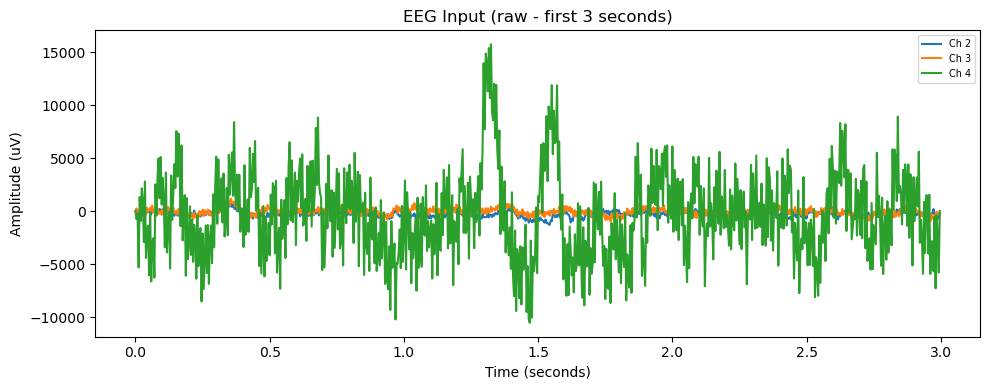

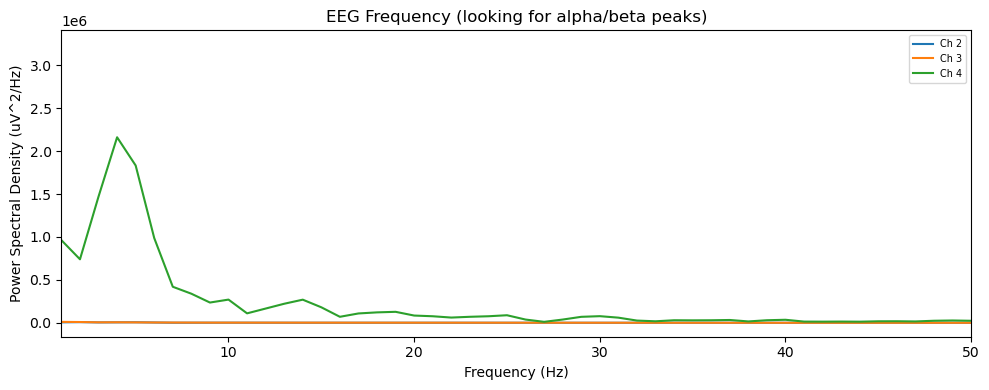

In [32]:
print(f"\nStep 1: Loading EEG recording from {csv_file}'...")
raw_data = load_eeg_csv(csv_file)
channel_count, total_samples = raw_data.shape

# drop the noisy channels
if channel_selection is not None:
    raw_data = raw_data[channel_selection, :]
    
n_channels = raw_data.shape[0]
duration = total_samples / sampling_rate

print(f"Total channels: {channel_count}. Kept {n_channels} selected channels.")
print(f"Processing {total_samples} samples ({duration:.2f} seconds at {sampling_rate:g} Hz)")

if channel_selection:
    channels_to_loop = channel_selection
else:
    channels_to_loop = range(n_channels)

# cleaned EEG data plot
time_axis = np.arange(min(total_samples, int(sampling_rate * 3))) / sampling_rate
fig, ax = plt.subplots(figsize=(10, 4))

for i, ch_idx in enumerate(channels_to_loop):
    ax.plot(time_axis, raw_data[i, :len(time_axis)], label=f"Ch {ch_idx}")

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude (uV)")
ax.set_title("EEG Input (raw - first 3 seconds)")
ax.legend(loc="upper right", fontsize="x-small")
plt.tight_layout()
plt.show()

# plot the frequencies
fig, ax = plt.subplots(figsize = (10,4))
for i, ch_idx in enumerate(channels_to_loop):
    freqs, psd = signal.welch(raw_data[i, :], fs=sampling_rate, nperseg=int(sampling_rate))
    ax.plot(freqs, psd, label = f"Ch {ch_idx}")
                              
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Spectral Density (uV^2/Hz)")
ax.set_title("EEG Frequency (looking for alpha/beta peaks)")
ax.set_xlim(1, 50)
ax.legend(loc="upper right", fontsize="x-small")
plt.tight_layout()
plt.show()



Step 1: Preprocessing (Bandpass filter: 1.0 - 50.0 Hz)...


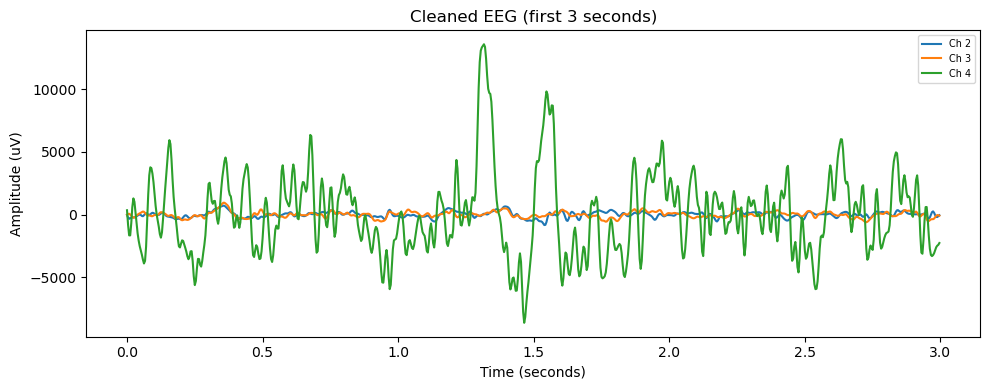

In [33]:
# step 1: preprocess
print("\nStep 1: Preprocessing (Bandpass filter: 1.0 - 50.0 Hz)...")
clean_data = apply_bandpass_filter(raw_data, sampling_rate, lowcut=1.0, highcut=50.0)

total_samples = clean_data.shape[1]
samples_to_plot = min(total_samples, int(sampling_rate * 3))
time_axis = np.arange(samples_to_plot) / sampling_rate

fig, ax = plt.subplots(figsize=(10, 4))

for i, ch_idx in enumerate(channels_to_loop):
    ax.plot(time_axis, clean_data[i, :samples_to_plot], label=f"Ch {ch_idx}")

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude (uV)")
ax.set_title("Cleaned EEG (first 3 seconds)")
ax.legend(loc="upper right", fontsize="x-small")
plt.tight_layout()
plt.show()


In [34]:
# step 2: setup the classifier
n_features = n_channels * 3  # theta, alpha, beta per channel
classifier = get_trained_classifier(sampling_rate, window_sec, channels_to_loop)

# step 3: slice data, extract features, classify
window_samples = int(window_sec * sampling_rate)
step_samples = int(window_samples * 0.5)  # 50% overlap to not miss any data,
# step_samples: means how far forward the window moves for the next prediction

print(f"\nStep 3: Extracting features & classifying windows ({window_sec}s windows)...")
print("=" * 60)
print(f"{'Time Window':<18} | {'Feature Count':<14} | {'Prediction':<15}")
print("-" * 60)

for start_idx in range(0, total_samples - window_samples + 1, step_samples):
    end_idx = start_idx + window_samples
    epoch = clean_data[:, start_idx:end_idx]
    # epoch: is a short, fixed-length chunk of time chopped out of a continuous stream of data
    features = extract_features(epoch, sampling_rate)
    prediction = classifier.predict([features])[0] if classifier else "N/A"
    # predict is a function of scikit-learn, it tells to model to make a decision at the end, 
    # this is the part when it decides right, left, leg or rest
    
    start_time = start_idx / sampling_rate
    end_time = end_idx / sampling_rate
    print(f"{start_time:5.1f}s - {end_time:5.1f}s   | {len(features):<14} | {prediction.upper()}")

print("=" * 60)
print("\nPipeline execution finished successfully.")

 Learning LEG from LegsTraining.csv...
[array([[            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [ 9.61471068e+04,  1.08201760e+03,  8.80000000e+01, ...,
         2.10000000e+01, -1.28000000e+02,  0.00000000e+00],
       [ 9.61471082e+04,  1.08201900e+03, -1.78000000e+02, ...,
         1.60000000e+01, -1.37000000e+02,  0.00000000e+00],
       ...,
       [ 9.57300726e+04,  6.64983400e+02, -8.70000000e+02, ...,
        -1.07000000e+02,  4.10000000e+01,  0.00000000e+00],
       [ 9.57300740e+04,  6.64984800e+02, -4.84000000e+02, ...,
        -1.12000000e+02,  1.30000000e+01,  0.00000000e+00],
       [ 9.57300753e+04,  6.64986100e+02, -7.70000000e+02, ...,
        -6.70000000e+01,  1.80000000e+01,  0.00000000e+00]],
      shape=(5073, 11))]
 Learning REST from RestTraining.csv...
[array([[            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [ 2.38

In [35]:
import csv

csv_file = "Hands4.csv"  # Replace with your actual file name if different

with open("Hands1.csv", 'r', encoding='utf-8') as f:
    print("--- First 15 lines of the CSV ---")
    for i in range(15):
        line = f.readline().strip()
        print(f"Line {i}: {line}")

--- First 15 lines of the CSV ---
Line 0: # Stream: FlexEEG (EEG) from DESKTOP-0N5AHDD
Line 1: # Time range (requested): 415s - 424s
Line 2: # Buffer range available: 0.0000s - 459.5834s
Line 3: timestamp,relative_time,Ch1,Ch2,Ch3,Ch4,Ch5,Ch6,Ch7,Ch8,Ch9
Line 4: 95480.0931128,415.0039,325,430,1501,-39,-96,1,-58,105,0
Line 5: 95480.0943741,415.0052,-237,190,4918,-30,-124,12,-30,133,0
Line 6: 95480.095814,415.0066,118,164,-344,-9,-138,41,-49,127,0
Line 7: 95480.1265419,415.0374,122,648,7584,-20,-121,28,-59,169,0
Line 8: 95480.1285554,415.0394,-124,234,1617,-32,-103,33,-99,148,0
Line 9: 95480.1305944,415.0414,201,788,2800,-13,-94,42,-89,151,0
Line 10: 95480.1320462,415.0429,-166,297,2656,-20,-83,21,-40,139,0
Line 11: 95480.1333051,415.0441,66,93,-4347,-6,-102,13,-46,102,0
Line 12: 95480.1377554,415.0486,48,329,2169,8,-61,7,-34,105,0
Line 13: 95480.1595815,415.0704,-101,-298,-1472,21,-123,-19,-8,132,0
Line 14: 95480.1610669,415.0719,252,192,2473,-21,-79,-22,21,148,0
